# Mosaic Plot With Residuals

In [7]:
options(repr.plot.width = 20, repr.plot.height = 12)

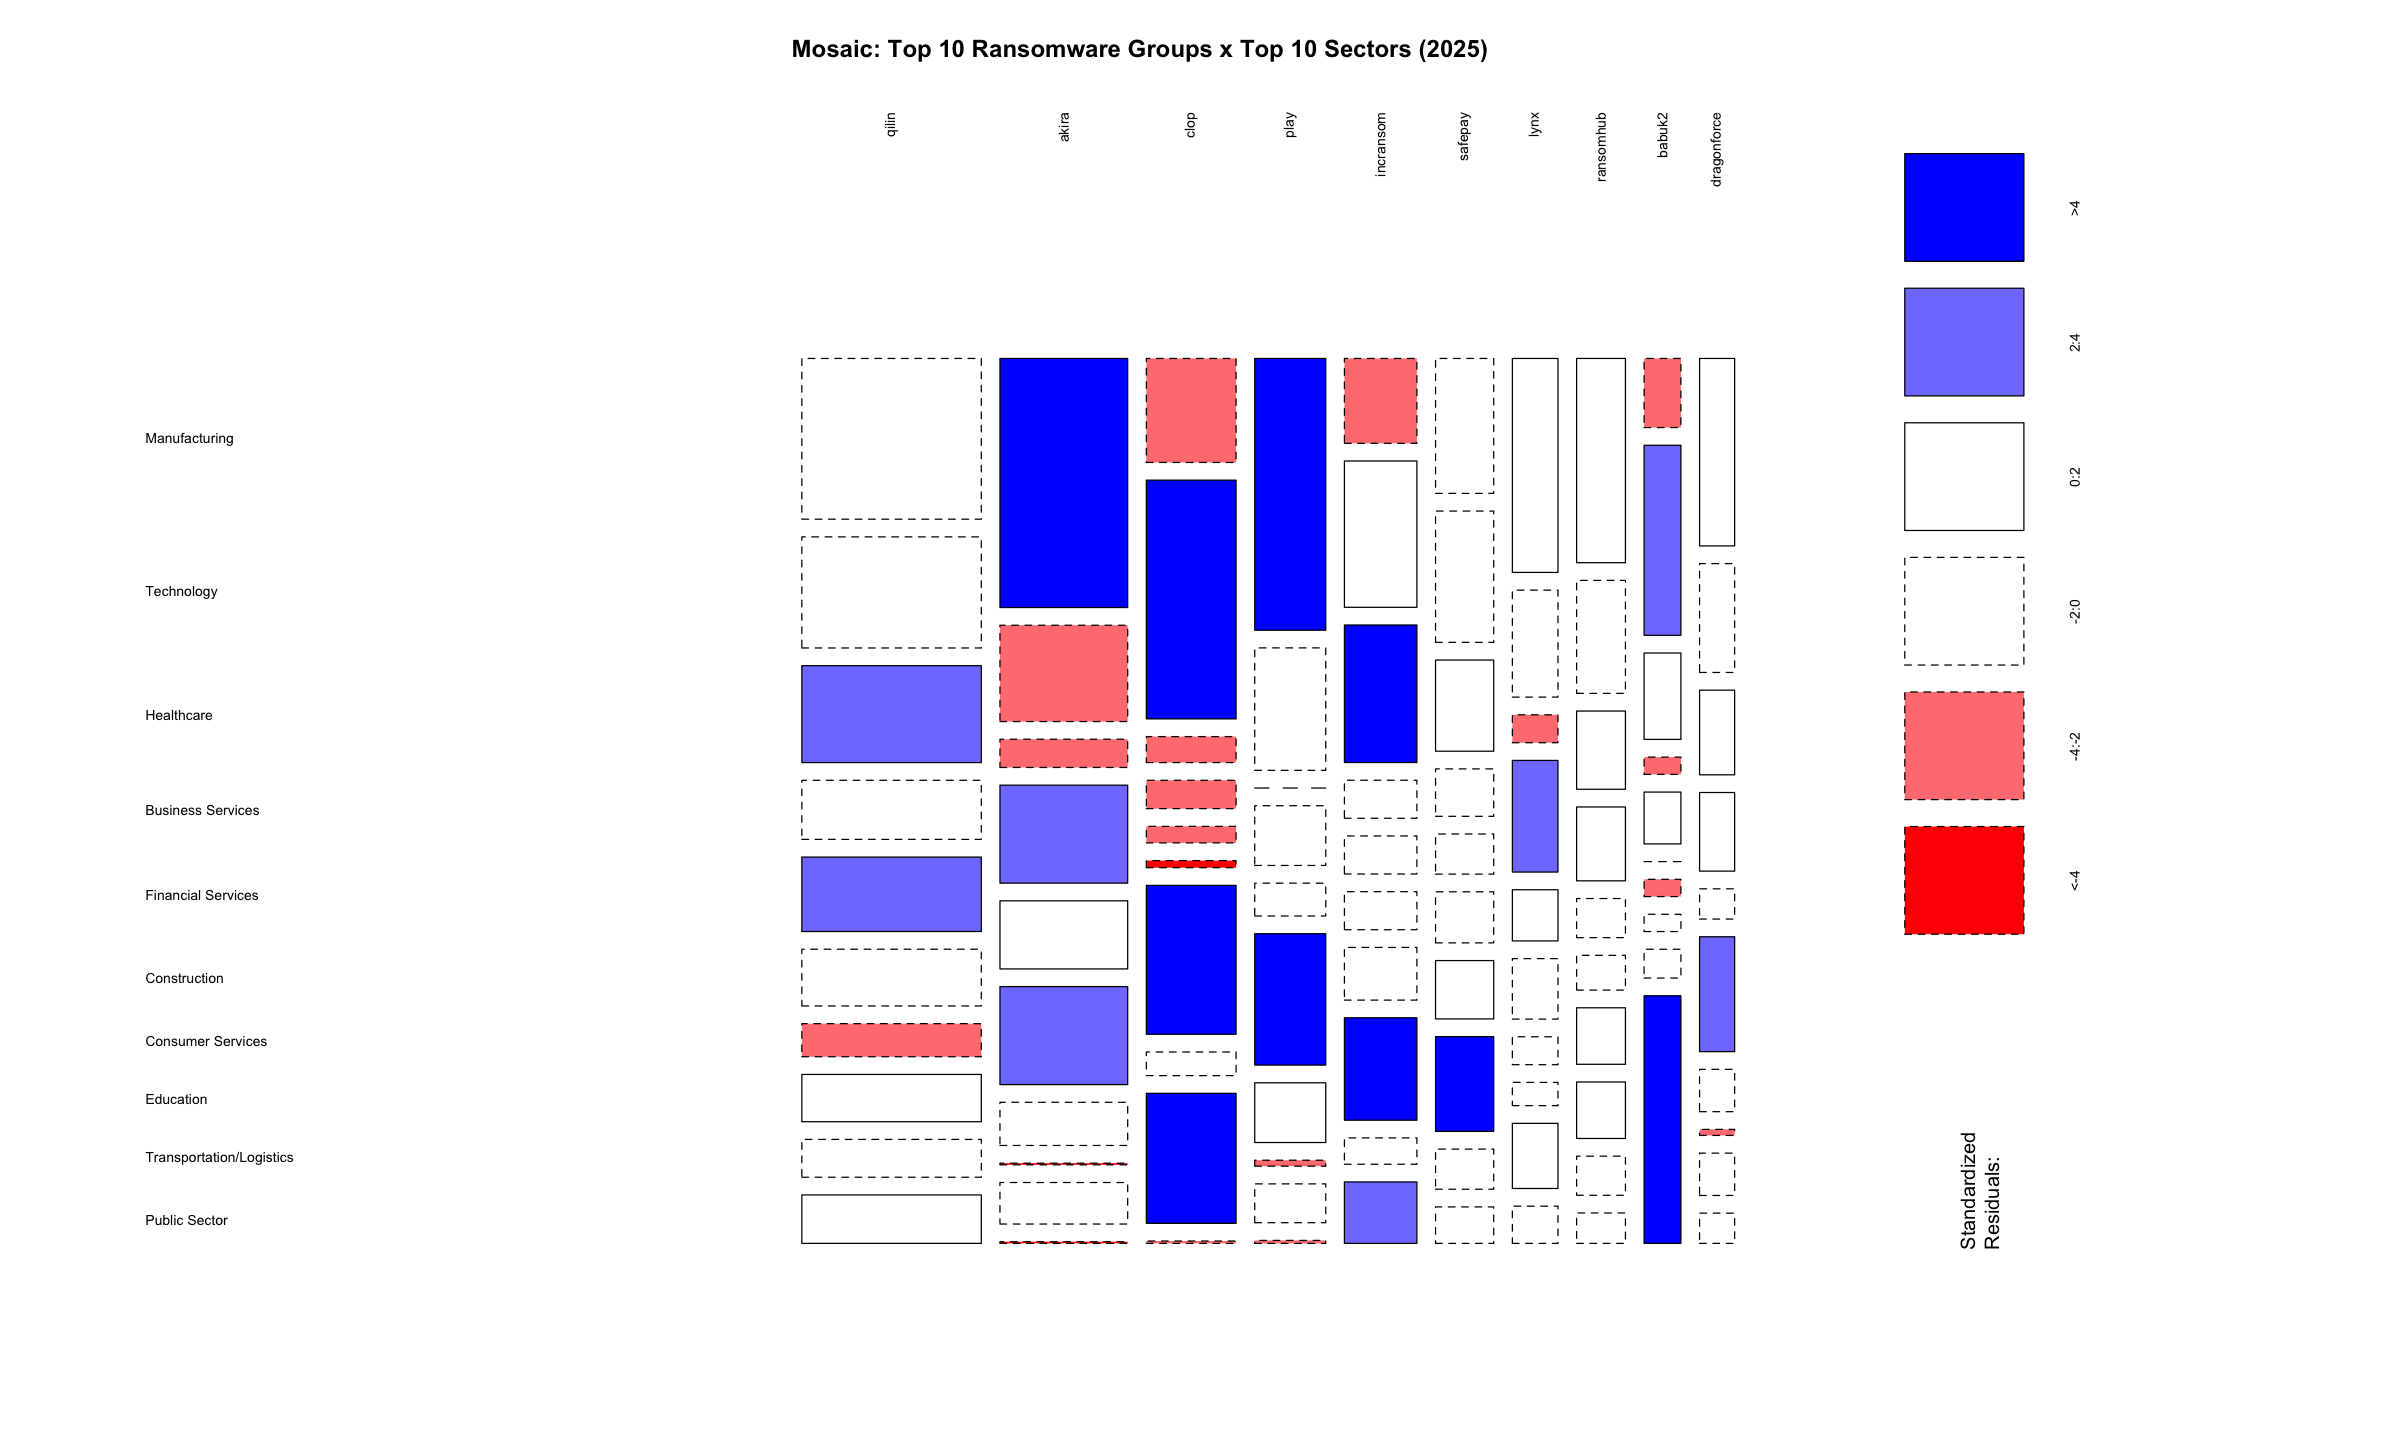

In [8]:
library(dplyr)

victims <- read.csv("/Users/dmk6603/Documents/ransom_victims/1-ransomware.live_data/data/victims.csv")

# Extract year from the discovered column
victims$year <- as.integer(format(as.Date(victims$discovered), "%Y"))

victims_2025 <- victims %>%
  filter(year == 2025, !is.na(activity), activity != "", activity != "Not Found")

top_groups <- names(sort(table(victims_2025$group_name), decreasing = TRUE))[1:10]
top_sectors <- names(sort(table(victims_2025$activity), decreasing = TRUE))[1:10]

victims_top <- victims_2025 %>%
  filter(group_name %in% top_groups, activity %in% top_sectors) %>%
  mutate(group_name = factor(group_name, levels = top_groups),
         activity = factor(activity, levels = top_sectors))

ct <- table(victims_top$group_name, victims_top$activity)

par(mar = c(8, 5, 4, 10), xpd = TRUE)

mosaicplot(ct,
           main = "Mosaic: Top 10 Ransomware Groups x Top 10 Sectors (2025)",
           color = TRUE,
           shade = TRUE,
           las = 2,
           cex.axis = 0.7)

# Mosaic Plot Table

In [3]:
library(dplyr)

victims <- read.csv("/Users/dmk6603/Documents/ransom_victims/1-ransomware.live_data/data/victims.csv")

victims$year <- as.integer(format(as.Date(victims$discovered), "%Y"))

victims_2025 <- victims %>%
  filter(year == 2025, !is.na(activity), activity != "", activity != "Not Found")

top_groups <- names(sort(table(victims_2025$group_name), decreasing = TRUE))[1:10]
top_sectors <- names(sort(table(victims_2025$activity), decreasing = TRUE))[1:10]

victims_top <- victims_2025 %>%
  filter(group_name %in% top_groups, activity %in% top_sectors) %>%
  mutate(group_name = factor(group_name, levels = top_groups),
         activity = factor(activity, levels = top_sectors))

ct <- table(victims_top$group_name, victims_top$activity)

chi <- chisq.test(ct)

cat("Chi-Square Statistic:", chi$statistic, "\n")
cat("Degrees of Freedom:", chi$parameter, "\n")
cat("P-value:", chi$p.value, "\n\n")

# Standardized residuals table (shows which cells deviate most)
cat("Standardized Residuals (Pearson):\n")
round(chi$stdres, 2)

Chi-Square Statistic: 893.3285 
Degrees of Freedom: 81 
P-value: 4.181045e-137 

Standardized Residuals (Pearson):


             
              Manufacturing Technology Healthcare Business Services
  qilin               -1.10      -2.22       4.33             -0.42
  akira                5.66      -3.00      -4.08              4.05
  clop                -4.15       7.02      -3.52             -3.10
  play                 5.24      -0.62      -5.14             -0.19
  incransom           -4.71       0.78       5.77             -1.96
  safepay             -1.80      -0.10       1.84             -1.06
  lynx                 1.72      -1.20      -2.31              3.14
  ransomhub            1.36      -0.96       0.84              0.77
  babuk2              -3.86       2.33       1.18             -2.54
  dragonforce          0.53      -0.97       1.05              0.91
             
              Financial Services Construction Consumer Services Education
  qilin                     3.79        -0.64             -3.29      1.68
  akira                     2.27         4.17             -1.46     -5.13
  

In [9]:
library(dplyr)

victims <- read.csv("/Users/dmk6603/Documents/ransom_victims/1-ransomware.live_data/data/victims.csv")
victims$year <- as.integer(format(as.Date(victims$discovered), "%Y"))

victims_2025 <- victims %>%
  filter(year == 2025, !is.na(activity), activity != "", activity != "Not Found")

top_groups <- names(sort(table(victims_2025$group_name), decreasing = TRUE))[1:10]
top_sectors <- names(sort(table(victims_2025$activity), decreasing = TRUE))[1:10]

victims_top <- victims_2025 %>%
  filter(group_name %in% top_groups, activity %in% top_sectors) %>%
  mutate(group_name = factor(group_name, levels = top_groups),
         activity = factor(activity, levels = top_sectors))

ct <- table(victims_top$group_name, victims_top$activity)
chi <- chisq.test(ct)
counts <- as.matrix(ct)
z <- round(chi$stdres, 2)

# Totali complessivi 2025 (tutte le categorie, non solo top10)
group_totals_all <- table(victims_2025$group_name)[top_groups]
sector_totals_all <- table(victims_2025$activity)[top_sectors]
grand_total <- nrow(victims_2025)

short <- c("Manufacturing"="Manuf.", "Technology"="Tech.", "Healthcare"="Health.",
           "Business Services"="Bus.Serv.", "Financial Services"="Fin.Serv.",
           "Construction"="Constr.", "Consumer Services"="Cons.Serv.",
           "Education"="Educ.", "Transportation/Logistics"="Transp.", "Public Sector"="Pub.Sect.")

headers <- ifelse(colnames(counts) %in% names(short), short[colnames(counts)], colnames(counts))

cat("\\begin{table}[ht]\n\\centering\n")
cat("\\caption{Observed Counts and Pearson Standardized Residuals: Top 10 Groups $\\times$ Top 10 Sectors (2025)}\n")
cat("\\label{tab:chi2_residuals}\n\\resizebox{\\textwidth}{!}{%\n")
cat("\\begin{tabular}{l", rep("c", ncol(counts)), "r}\n\\hline\n", sep = "")
cat("Group & ", paste(headers, collapse = " & "), " & Total \\\\\n\\hline\n", sep = "")

for (i in 1:nrow(counts)) {
  cells <- sapply(1:ncol(counts), function(j) {
    val <- paste0(counts[i,j], " (", z[i,j], ")")
    if (abs(z[i,j]) > 3) paste0("\\textbf{", val, "}")
    else if (abs(z[i,j]) > 2) paste0("\\textit{", val, "}")
    else val
  })
  cat(rownames(counts)[i], " & ", paste(cells, collapse = " & "), " & ", group_totals_all[i], " \\\\\n", sep = "")
}

cat("\\hline\nTotal & ", paste(sector_totals_all, collapse = " & "), " & ", grand_total, " \\\\\n", sep = "")

cat("\\hline\n\\end{tabular}%\n}\n")
cat("\\vspace{0.3em}\n\n")
cat("\\footnotesize{$\\chi^2 = ", round(chi$statistic, 2), "$, $df = ", chi$parameter,
    "$, $p < 0.001$. \\textbf{Bold}: $|z| > 3.0$ (strong association); ",
    "\\textit{italic}: $2.0 < |z| \\leq 3.0$ (moderate association). ",
    "Row and column totals reflect all 2025 victims, including sectors and groups outside the top 10.}\n", sep = "")
cat("\\end{table}\n")

\begin{table}[ht]
\centering
\caption{Observed Counts and Pearson Standardized Residuals: Top 10 Groups $\times$ Top 10 Sectors (2025)}
\label{tab:chi2_residuals}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccccccccr}
\hline
Group & Manuf. & Tech. & Health. & Bus.Serv. & Fin.Serv. & Constr. & Cons.Serv. & Educ. & Transp. & Pub.Sect. & Total \\
\hline
qilin & 136 (-1.1) & \textit{94 (-2.22)} & \textbf{82 (4.33)} & 50 (-0.42) & \textbf{63 (3.79)} & 48 (-0.64) & \textbf{28 (-3.29)} & 40 (1.68) & 32 (-1.86) & 41 (1.78) & 692 \\
akira & \textbf{150 (5.66)} & \textit{58 (-3)} & \textbf{17 (-4.08)} & \textbf{59 (4.05)} & \textit{41 (2.27)} & \textbf{59 (4.17)} & 26 (-1.46) & \textbf{1 (-5.13)} & 25 (-1.05) & \textbf{1 (-5.17)} & 518 \\
clop & \textbf{44 (-4.15)} & \textbf{101 (7.02)} & \textbf{11 (-3.52)} & \textbf{12 (-3.1)} & \textbf{7 (-3.39)} & \textbf{3 (-5.01)} & \textbf{63 (9.04)} & 10 (-1.63) & \textbf{55 (8.13)} & \textbf{1 (-4.13)} & 346 \\
play & \textbf{91 (5.24)} & 41 (-0.62) 